In [116]:
import pandas as pd
import matplotlib.pyplot as plt

In [117]:
FILEPATH = "../data/out.csv"
FREQUENCY = 60 #Hz
START = 10
END = 12

In [118]:
import numpy as np

df = pd.read_csv(FILEPATH, sep=",", header=None, names=["Thrust", "X", "Y", "Z", "QX", "QY", "QZ", "QW"])
df['time'] = df.index * (1 / FREQUENCY)
df['distance'] = np.sqrt(
    (df['X'] - df['X'].shift(1))**2 +
    (df['Y'] - df['Y'].shift(1))**2 +
    (df['Z'] - df['Z'].shift(1))**2
)
df.loc[0, 'distance'] = 0  # Set first distance to 0
df.head()

,Thrust,X,Y,Z,QX,QY,QZ,QW,time,distance
0,10000.0,-4.538985,0.496330,-2.240390,0.001492,-0.909585,-0.055393,0.411807,0.000000,0.000000
1,10000.0,-4.539178,0.496443,-2.240623,0.003752,-0.910555,-0.053536,0.409890,0.016667,0.000323
2,10000.0,-4.538641,0.495415,-2.241196,-0.006994,-0.906785,-0.048222,0.418769,0.033333,0.001294
3,10000.0,-4.539489,0.495806,-2.242373,-0.010335,-0.910842,-0.042627,0.410419,0.050000,0.001502
4,10000.0,-4.539120,0.495236,-2.242364,-0.013439,-0.909173,-0.040228,0.414253,0.066667,0.000678


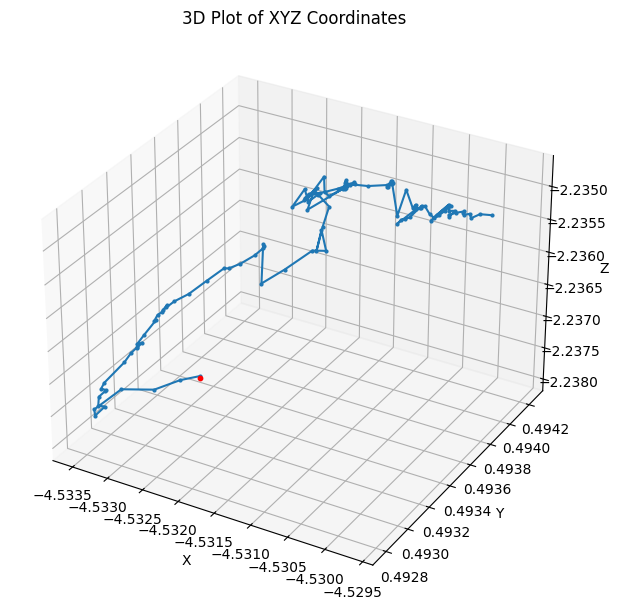

In [119]:
# df = pd.read_csv(FILEPATH, sep=",", header=None, names=["Thrust", "X", "Y", "Z", "QX", "QY", "QZ", "QW"])
df = df.iloc[FREQUENCY*START:FREQUENCY*END].reset_index(drop=True)


fig = plt.figure(figsize=(8, 6), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
ax.plot(df['X'], df['Y'], df['Z'], marker='o', linestyle='-', markersize=2)
ax.scatter(df['X'][0], df['Y'][0], df['Z'][0], c='r', marker='o', s=10, label='Data Points')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Plot of XYZ Coordinates')
plt.show()

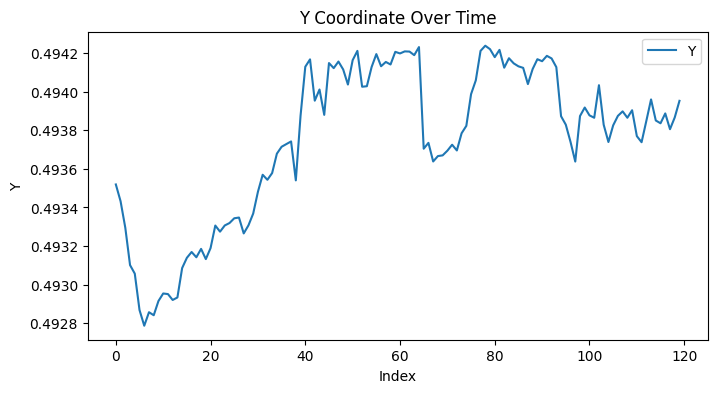

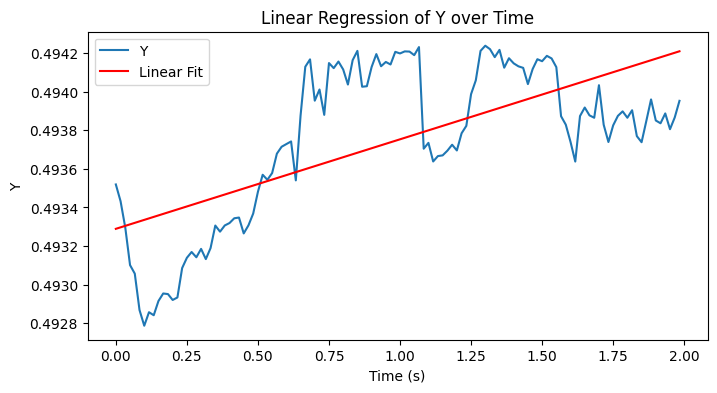

Linear coefficient (slope): 0.0004643146338020076
Intercept: 0.49328932443187257


In [120]:
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(8, 4))
plt.plot(df.index, df['Y'], label='Y')
plt.xlabel('Index')
plt.ylabel('Y')
plt.title('Y Coordinate Over Time')
plt.legend()
plt.show()

# Create time variable based on index and frequency
time = df.index * (1 / FREQUENCY)
Y = df['Y'].values.reshape(-1, 1)

# Fit linear regression
model = LinearRegression()
model.fit(time.values.reshape(-1, 1), Y)

# Predict Z using the fitted model
Y_pred = model.predict(time.values.reshape(-1, 1))

# Plot regression line
plt.figure(figsize=(8, 4))
plt.plot(time, df['Y'], label='Y')
plt.plot(time, Y_pred, color='red', label='Linear Fit')
plt.xlabel('Time (s)')
plt.ylabel('Y')
plt.title('Linear Regression of Y over Time')
plt.legend()
plt.show()

print("Linear coefficient (slope):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

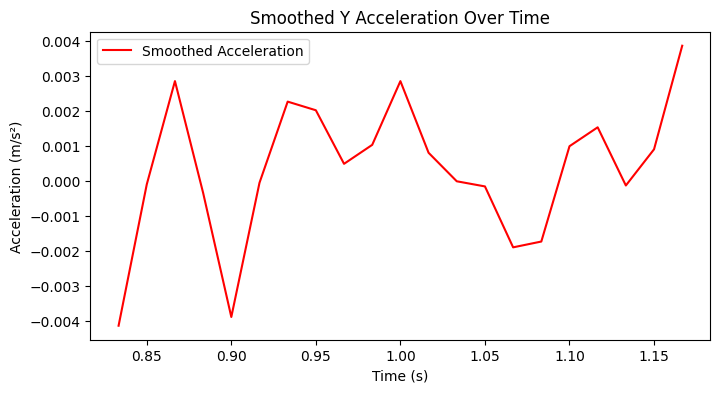

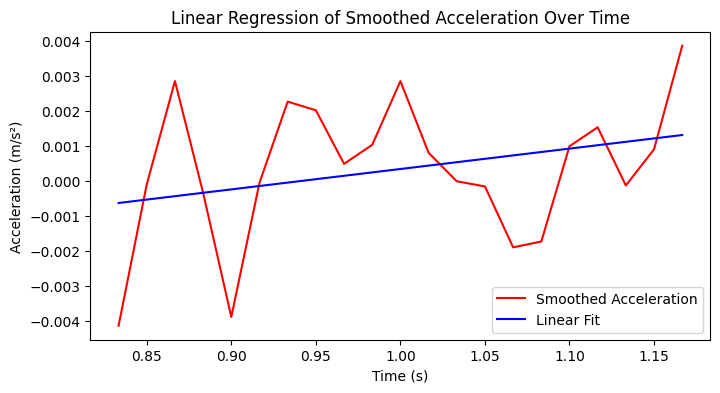

Acceleration linear coefficient (slope): 0.005827012843329341
Acceleration intercept: -0.005484715906558519


In [124]:
# Calculate acceleration by differentiating velocity (which is the diff of Z over time)
velocity = np.gradient(df['distance'], time)
acceleration = np.gradient(velocity, time)

window_size = 100  # You can adjust the window size for more/less smoothing
acceleration_smooth = pd.Series(acceleration).rolling(window=window_size, center=True).mean()

plt.figure(figsize=(8, 4))
# plt.plot(time, acceleration, label='Raw Acceleration', alpha=0.5)
plt.plot(time, acceleration_smooth, label='Smoothed Acceleration', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Smoothed Y Acceleration Over Time')
plt.legend()
plt.show()

# Remove NaN values for regression
valid_idx = ~acceleration_smooth.isna()
time_valid = time[valid_idx].values.reshape(-1, 1)
accel_valid = acceleration_smooth[valid_idx].values.reshape(-1, 1)

# Fit linear regression
accel_model = LinearRegression()
accel_model.fit(time_valid, accel_valid)
accel_pred = accel_model.predict(time_valid)

# Plot regression line
plt.figure(figsize=(8, 4))
plt.plot(time, acceleration_smooth, label='Smoothed Acceleration', color='red')
plt.plot(time_valid, accel_pred, color='blue', label='Linear Fit')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Linear Regression of Smoothed Acceleration Over Time')
plt.legend()
plt.show()

print("Acceleration linear coefficient (slope):", accel_model.coef_[0][0])
print("Acceleration intercept:", accel_model.intercept_[0])

In [122]:
df

,Thrust,X,Y,Z,QX,QY,QZ,QW,time,distance
0,24500.0,-4.533062,0.493520,-2.237956,0.010103,-0.911677,-0.012691,0.410588,10.000000,0.000227
1,24500.0,-4.532921,0.493433,-2.237738,0.007711,-0.911298,-0.013541,0.411452,10.016667,0.000274
2,25000.0,-4.532978,0.493295,-2.237609,0.006985,-0.911210,-0.013529,0.411661,10.033333,0.000197
3,25000.0,-4.533025,0.493101,-2.237476,0.005359,-0.911453,-0.014402,0.411116,10.050000,0.000240
4,25000.0,-4.533426,0.493057,-2.237536,0.001690,-0.912748,-0.013383,0.408299,10.066667,0.000408
...,...,...,...,...,...,...,...,...,...,...
115,27500.0,-4.529864,0.493837,-2.234881,-0.003860,-0.923386,-0.021015,0.383278,11.916667,0.000043
116,27500.0,-4.529862,0.493888,-2.234937,-0.003604,-0.923608,-0.020818,0.382755,11.933333,0.000076
117,27500.0,-4.529732,0.493806,-2.234850,-0.001758,-0.923308,-0.021848,0.383435,11.950000,0.000177
118,27500.0,-4.529697,0.493867,-2.234865,-0.001823,-0.923609,-0.021574,0.382724,11.966667,0.000072
